In [1]:
import xmlrpc.client
server = xmlrpc.client.ServerProxy('http://localhost:1080/RPC2')
methods = server.system.listMethods()
for m in methods:
    print(m)
    try:
        print("  sig:", server.system.methodSignature(m))
        print("  help:", server.system.methodHelp(m))
    except:
        pass

plecs.simulate
plecs.codegen
plecs.load
plecs.webserver
plecs.scope
plecs.get
plecs.statistics
plecs.set
plecs.close
plecs.getModelTree
plecs.analyze
system.listMethods
system.methodHelp


In [ ]:
import xmlrpc.client
from pathlib import Path

class PLECSRPCSimulator:
    def __init__(self, model_path, port=1080):
        self.model_path = str(Path(model_path).resolve()).replace('\\', '/')
        self.model_name = Path(model_path).stem
        self.server = xmlrpc.client.ServerProxy(f'http://localhost:{port}/RPC2')
        
        try:
            self.server.plecs.load(self.model_path)
            print(f"✓ Loaded {self.model_name}")
        except xmlrpc.client.Fault as e:
            if "already" not in e.faultString.lower():
                raise

    def simulate(self, params, t_end):
        opt_struct = {
            'ModelVars': params,
            'SolverOpts': {'StopTime': float(t_end),
                           'Solver': 'auto',
                           'FixedStep': False}   # float, not str
        }
        return self.server.plecs.simulate(self.model_name, opt_struct)

if __name__ == '__main__':
    sim = PLECSRPCSimulator(r'..\models\buck_converter.plecs')
    
    result = sim.simulate({
        'L':               100e-6,
        'C':               100e-6,
        'ESR_L':           0.1,
        'ESR_C':           0.05,
        'R_load':          10.0,
        'alpha':           0.5,
        'cycle_frequency': 100e3,
    }, t_end=0.01)
    
    print("Result type:", type(result))
    print("Keys:", list(result.keys()) if isinstance(result, dict) else "not a dict")
    print("Preview:", str(result)[:500])

✓ Loaded buck_converter
Result type: <class 'dict'>
Keys: ['Time', 'Values']
Preview: {'Time': [0.0, 2.3569283268220856e-08, 1.4141569960932514e-07, 7.306477813148465e-07, 3.6768081898424535e-06, 4.999999999999858e-06, 5e-06, 9.999999999999716e-06, 1e-05, 1.4999999999999575e-05, 1.5000000000000002e-05, 1.9999999999999432e-05, 2e-05, 2.499999999999929e-05, 2.5e-05, 2.999999999999915e-05, 3.0000000000000004e-05, 3.499999999999901e-05, 3.5000000000000004e-05, 3.9999999999998865e-05, 4e-05, 4.499999999999872e-05, 4.5e-05, 4.999999999999858e-05, 5e-05, 5.499999999999844e-05, 5.5e-05, 


In [6]:
import numpy as np
import matplotlib.pyplot as plt

t = np.array(result['Time'])
v = np.array(result['Values'])

print(f"Time shape: {t.shape}")
print(f"Values shape: {v.shape}")
print(f"Simulated from {t[0]*1e3:.3f} ms to {t[-1]*1e3:.3f} ms")
print(f"Number of points: {len(t)}")

Time shape: (4005,)
Values shape: (4, 4005)
Simulated from 0.000 ms to 10.000 ms
Number of points: 4005


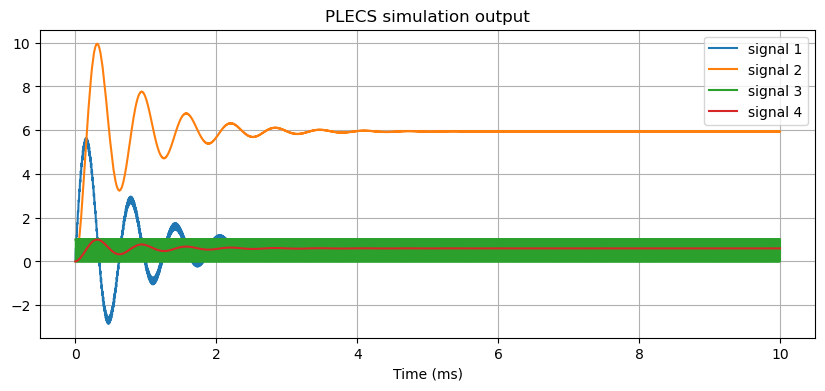

In [7]:
plt.figure(figsize=(10, 4))
if v.ndim == 1:
    plt.plot(t * 1e3, v)
    plt.ylabel('signal')
else:
    for i, signal in enumerate(v):
        plt.plot(t * 1e3, signal, label=f'signal {i+1}')
    plt.legend()
plt.xlabel('Time (ms)')
plt.grid(True)
plt.title('PLECS simulation output')
plt.show()